100%|██████████| 9.91M/9.91M [00:00<00:00, 55.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.65MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 13.9MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.15MB/s]


Epoch [0/100]  Loss D: 1.2189, Loss G: 0.7852
Epoch [1/100]  Loss D: 1.1982, Loss G: 0.7802
Epoch [2/100]  Loss D: 1.0929, Loss G: 1.0445
Epoch [3/100]  Loss D: 1.1613, Loss G: 1.0373
Epoch [4/100]  Loss D: 1.2635, Loss G: 0.8546
Epoch [5/100]  Loss D: 1.1933, Loss G: 0.9788
Epoch [6/100]  Loss D: 1.2533, Loss G: 0.7965
Epoch [7/100]  Loss D: 1.1333, Loss G: 1.6643
Epoch [8/100]  Loss D: 1.2114, Loss G: 1.2190
Epoch [9/100]  Loss D: 1.2702, Loss G: 0.7423
Epoch [10/100]  Loss D: 1.3339, Loss G: 0.9874
Epoch [11/100]  Loss D: 1.3208, Loss G: 0.6210
Epoch [12/100]  Loss D: 1.2724, Loss G: 0.7301
Epoch [13/100]  Loss D: 1.4021, Loss G: 0.6634
Epoch [14/100]  Loss D: 1.3592, Loss G: 0.7053
Epoch [15/100]  Loss D: 1.3114, Loss G: 1.2512
Epoch [16/100]  Loss D: 1.2440, Loss G: 0.9796
Epoch [17/100]  Loss D: 1.3328, Loss G: 0.7738
Epoch [18/100]  Loss D: 1.3810, Loss G: 0.8078
Epoch [19/100]  Loss D: 1.3165, Loss G: 0.7459
Epoch [20/100]  Loss D: 1.3874, Loss G: 0.7421
Epoch [21/100]  Loss D:

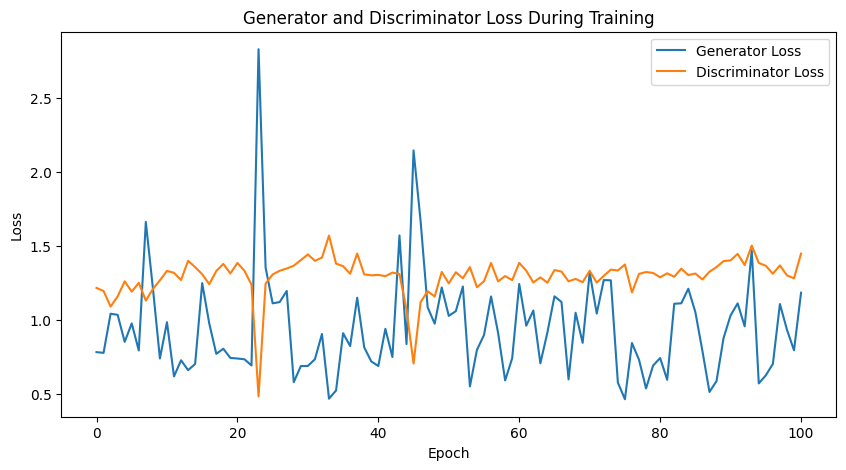

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt
import os

# Create output directory
os.makedirs("samples", exist_ok=True)

# Hyperparameters
latent_dim = 100
batch_size = 128
epochs = 100
lr = 0.0002
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data Loader
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

dataloader = DataLoader(
    datasets.MNIST(".", train=True, download=True, transform=transform),
    batch_size=batch_size, shuffle=True
)

# Generator Model
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(True),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(True),
            nn.Linear(256, 784),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.model(z)
        return img.view(z.size(0), 1, 28, 28)

# Discriminator Model
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        return self.model(img)

# Initialize models
generator = Generator().to(device)
discriminator = Discriminator().to(device)

# Loss and optimizers
criterion = nn.BCELoss()
opt_G = optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
opt_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))

# For plotting
losses_G = []
losses_D = []

# Fixed noise for image generation
fixed_noise = torch.randn(64, latent_dim).to(device)

# Training loop
for epoch in range(epochs + 1):
    for i, (real_imgs, _) in enumerate(dataloader):
        real_imgs = real_imgs.to(device)
        batch_size = real_imgs.size(0)

        # Train Discriminator
        z = torch.randn(batch_size, latent_dim).to(device)
        fake_imgs = generator(z).detach()
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        D_real = discriminator(real_imgs)
        D_fake = discriminator(fake_imgs)

        loss_D = criterion(D_real, real_labels) + criterion(D_fake, fake_labels)
        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # Train Generator
        z = torch.randn(batch_size, latent_dim).to(device)
        fake_imgs = generator(z)
        output = discriminator(fake_imgs)
        loss_G = criterion(output, real_labels)

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

    losses_D.append(loss_D.item())
    losses_G.append(loss_G.item())

    # Save sample images
    if epoch in [0, 50, 100]:
        with torch.no_grad():
            fake_imgs = generator(fixed_noise).detach().cpu()
        save_image(make_grid(fake_imgs, nrow=8, normalize=True), f"samples/epoch_{epoch}.png")

    print(f"Epoch [{epoch}/{epochs}]  Loss D: {loss_D.item():.4f}, Loss G: {loss_G.item():.4f}")

# Plot losses
plt.figure(figsize=(10, 5))
plt.plot(losses_G, label="Generator Loss")
plt.plot(losses_D, label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Generator and Discriminator Loss During Training")
plt.savefig("samples/loss_plot.png")
plt.show()
